# Country-Borders Geometry — End-to-End Pipeline

Probes how Llama-3.1-8B represents European country geometry, using directional border queries as the behavioral hook.

**Why borders.** Each prompt requires the model to place a country in its internal geometry and step in a given direction. Multiple distinct (entity, direction) prompts map to the same answer country, so averaging activations at the answer position across these prompts isolates the answer-country representation from any specific input entity. Example: France-centroid is built from `(Spain, NE)`, `(Italy, NW)`, `(Germany, W)`, `(Switzerland, W)`, `(Belgium, S)`.

**Dataset (post-cleanup):** 30 European countries (Iceland, Britain, Ireland dropped — no useful neighbors), 8 compass directions (N, NE, E, SE, S, SW, W, NW), 4 paraphrase templates. **146 geographically valid `(country, direction)` cells × 4 templates = 584 prompts.** 7 cells removed after baseline diagnosis revealed the model doesn't recognize:
- Kaliningrad as Russian (`(Lithuania, W)` / `(Lithuania, SW) → Russia`)
- "Tunneling" through non-set countries (`(Belgium, SE) → Germany` via Luxembourg, `(Albania, NE) → Serbia` and `(Serbia, S)` / `(Serbia, SW) → Albania` via Kosovo)
- Sea-jump borders the model strongly disagrees with (`(Norway, S) → Denmark` across Skagerrak; the model picks Sweden which is SE)

Multi-neighbor cells (e.g. `(Germany, W) → [France, Belgium, Netherlands]`) use the primary as the canonical answer; the custom checker accepts any valid neighbor.

**Baseline results on Llama-3.1-8B (base):**
- Strict accuracy: 65.1% (380/584)
- Multi-neighbor accuracy: 67.6% (395/584)
- Best direction: S (85% multi); worst: NW (60%)
- `prob_accuracy = 19%` — model is genuinely uncertain, more so than for fact-retrieval tasks

**Research questions:**
- **Layer localization:** At which (layer, token_position) is country-geometric reasoning encoded?
- **Subspace + geometry:** Does the per-answer-country centroid manifold recapitulate European geography? Linguistic family? Cold War East/West? EU membership?

**Practical note:** All cells write runner configs to this session and route artifacts to `agent_logs/.../artifacts/country_borders/` via the `--experiment-root` flag. Old `nationality_capitals` artifacts are under `_archived_nationality_capitals/`.

**Timing on CPU:**
- §1 Baseline: ~2.5 hours for 584 valid + 376 invalid prompts
- §2 Locate: many hours — wants a GPU
- §3 Subspace: ~10–20 min

In [2]:
import os
import json
import subprocess
from pathlib import Path
from IPython.display import Image, display

import causalab

PROJECT_ROOT = Path(causalab.__file__).resolve().parent.parent
SESSION_NAME = open(PROJECT_ROOT / "agent_logs" / ".current").read().strip()
SESSION_DIR = PROJECT_ROOT / "agent_logs" / SESSION_NAME
RUNNERS_DIR = SESSION_DIR / "code" / "configs" / "runners" / "country_borders"
ARTIFACTS_ROOT = SESSION_DIR / "artifacts" / "country_borders" / "llama31_8b"

RUNNERS_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_ROOT.mkdir(parents=True, exist_ok=True)
print(f'Session:        {SESSION_NAME}')
print(f'Runner configs: {RUNNERS_DIR}')
print(f'Artifacts root: {ARTIFACTS_ROOT}')


def save_session_runner(name: str, yaml_str: str) -> Path:
    """Write a runner YAML to the session's code/configs/runners/ tree."""
    p = RUNNERS_DIR / f'{name}.yaml'
    p.write_text(yaml_str)
    return p


def run_session(name: str) -> int:
    """Invoke scripts/run_exp.sh with the session-scoped experiment-root."""
    cmd = [
        'bash', 'scripts/run_exp.sh',
        '--experiment-root', str(ARTIFACTS_ROOT),
        name,
    ]
    print('+', ' '.join(cmd))
    rc = subprocess.run(cmd, cwd=PROJECT_ROOT)
    return rc.returncode

Session:        2026-05-13--nationality-geometry--clever-falcon
Runner configs: /home/danielaush/Documents/what-is-a-feature/causalab/agent_logs/2026-05-13--nationality-geometry--clever-falcon/code/configs/runners/country_borders
Artifacts root: /home/danielaush/Documents/what-is-a-feature/causalab/agent_logs/2026-05-13--nationality-geometry--clever-falcon/artifacts/country_borders/llama31_8b


## §1. Baseline — does the model solve the task?

Enumerate all 30 countries × 8 directions × 4 templates = 960 (country, direction, template) combinations. Of these, **146 × 4 = 584 are geographically valid** (have a defined primary neighbor in the country set); the remaining 376 are ocean-facing, border non-set countries, or are cells the model is known to disagree with (Kaliningrad / tunneled / sea-jump). The framework enumerates all 960 but the correct-only filter naturally drops the 376 invalid cells downstream.

Baseline outputs:
- `accuracy.json` — overall and per-class accuracy (strict equality against primary neighbor's first BPE token)
- `train_samples.json` — full enumeration of prompts and expected answers
- `top_logits.json` — top-10 logits per example (use this for the post-hoc multi-neighbor accuracy + per-direction breakdown)
- `confusion_heatmap.png` — visual

Strict-equality scoring against the primary undercounts multi-neighbor cells (only 18/146 cells have alts, contributes only ~2 pp). The bigger story is in the per-direction and per-input-country breakdown — see the diagnostic cell below.

In [ ]:
baseline_yaml = '''# @package _global_
defaults:
  - /base
  - /task: country_borders
  - /model: llama31_8b
  - /analysis/baseline
  - _self_
task:
  enumerate_all: true
  target_variable: country
baseline:
  visualization:
    figure_format: png
'''
p = save_session_runner('country_borders_baseline', baseline_yaml)
print(f'Wrote {p}')

In [ ]:
# Run the baseline analysis. ~2 hours on CPU; ~5 min on a single H100.
rc = run_session('country_borders_baseline')
assert rc == 0, f'baseline run failed (rc={rc})'

In [6]:
baseline_dir = ARTIFACTS_ROOT / 'baseline'
print(f'Contents of {baseline_dir}:')
print(sorted(p.name for p in baseline_dir.iterdir()))

Contents of /home/danielaush/Documents/what-is-a-feature/causalab/agent_logs/2026-05-13--nationality-geometry--clever-falcon/artifacts/country_borders/llama31_8b/baseline:
['accuracy.json', 'confusion_heatmap.png', 'counterfactual_sanity.json', 'full_output_dists.safetensors', 'ground_truth_dim0.png', 'metadata.json', 'per_class_output_dists.safetensors', 'test_samples.json', 'top_logits.json', 'train_samples.json']


In [7]:
with open(baseline_dir / 'accuracy.json') as f:
    print(json.dumps(json.load(f), indent=2))

{
  "accuracy": 0.39791666666666664,
  "correct": 382,
  "total": 960,
  "prob_accuracy": 0.19059635814507297
}


In [8]:
with open(baseline_dir / 'train_samples.json') as f:
    samples = json.load(f)['samples']
print(f'Total examples: {len(samples)}')
print('First 3:')
for s in samples[:3]:
    print(json.dumps(s, indent=2))

Total examples: 960
First 3:
{
  "raw_input": "Q: Which country lies to the north of France?\nA:",
  "raw_output": " Belgium"
}
{
  "raw_input": "Q: What country borders France on the north?\nA:",
  "raw_output": " Belgium"
}
{
  "raw_input": "Q: To the north of France is the country of\nA:",
  "raw_output": " Belgium"
}


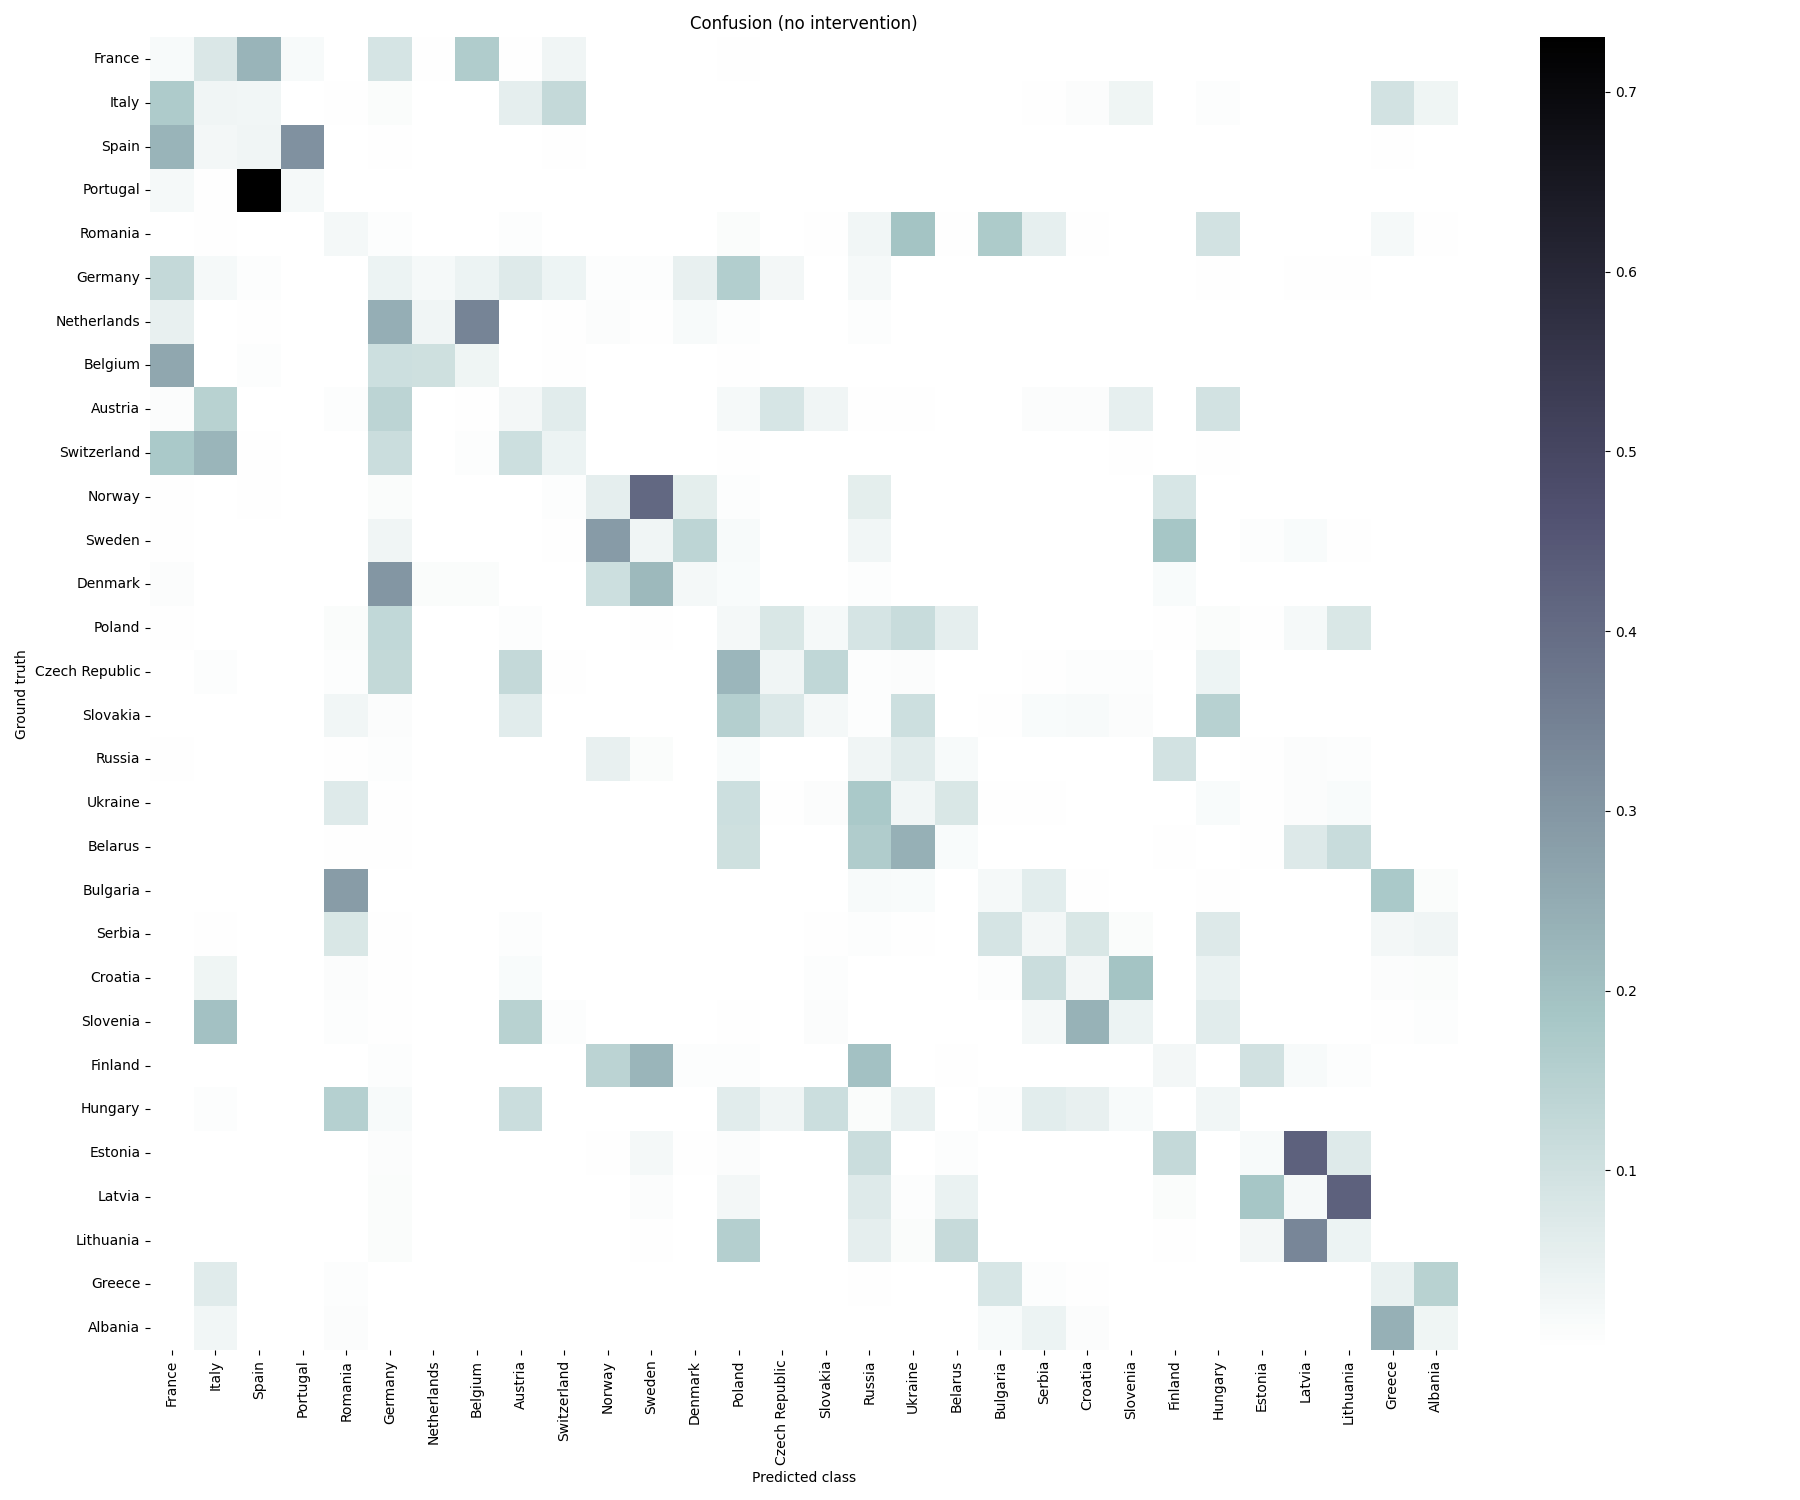

In [9]:
confusion_png = baseline_dir / 'confusion_heatmap.png'
if confusion_png.exists():
    display(Image(filename=str(confusion_png)))
else:
    print(f'(no {confusion_png.name} — check artifact dir contents above)')

## §2. Locate — where is country-border reasoning encoded?

Sweep `interchange` interventions across a range of layers (Llama-3.1-8B has 32) at each token position. For each (layer, position) cell, the score reports how reliably patching activations from a counterfactual source steers the output to the counterfactual's expected neighbor.

We use `change_country` as the counterfactual (direction and template held fixed) to isolate country-position identity from direction/format effects. The `target_variable: country` directs scoring to use answer-country labels.

**Note on cost:** Locate scan on 616 prompts × 7 layers × 3 token positions takes ~5+ hours on CPU. If you want to skip, the subspace cell defaults to (layer 24, last_token) from v1's capital task — that's a reasonable starting guess but may not be optimal for border reasoning. Re-run locate if you have GPU time.

In [3]:
locate_yaml = '''# @package _global_
defaults:
  - /base
  - /task: country_borders
  - /model: llama31_8b
  - /analysis/locate
  - _self_
task:
  enumerate_all: true
  resample_variable: country  # change_country counterfactuals
  target_variable: country
  intervention_metric: string_match
locate:
  method: interchange
  mode: pairwise
  layers: [0, 8, 12, 16, 20, 24, 28]
  n_steer: 16
  visualization:
    figure_format: png
'''
p = save_session_runner('country_borders_locate', locate_yaml)
print(f'Wrote {p}')

Wrote /home/danielaush/Documents/what-is-a-feature/causalab/agent_logs/2026-05-13--nationality-geometry--clever-falcon/code/configs/runners/country_borders/country_borders_locate.yaml


In [4]:
# Run the locate analysis. On CPU this is many hours — really wants a GPU.
# Skip and jump to §3 if you want to use a reasonable default (24, last_token).
rc = run_session('country_borders_locate')
assert rc == 0, f'locate run failed (rc={rc})'

+ bash scripts/run_exp.sh --experiment-root /home/danielaush/Documents/what-is-a-feature/causalab/agent_logs/2026-05-13--nationality-geometry--clever-falcon/artifacts/country_borders/llama31_8b country_borders_locate


+ session-local code: /home/danielaush/Documents/what-is-a-feature/causalab/agent_logs/2026-05-13--nationality-geometry--clever-falcon/code (PYTHONPATH + Hydra searchpath)


[2026-05-14 22:40:34,267][__main__][INFO] - === Step: locate (locate) ===
[2026-05-14 22:40:37,397][causalab.io.pipelines][INFO] - Loading model: meta-llama/Llama-3.1-8B (device=cpu)


Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00, 179.28it/s]


[2026-05-14 22:40:39,108][causalab.analyses.locate.main][INFO] - Locate scan over variables: ['country']
[2026-05-14 22:40:39,109][causalab.analyses.locate.main][INFO] - === Locate: target_variable=country ===
[2026-05-14 22:40:39,311][causalab.runner.helpers][INFO] - Exhaustive enumeration: 960 unique input combinations (resample_variable=country)
[2026-05-14 22:40:39,313][causalab.analyses.locate.run_interchange][INFO] - Loaded base accuracy from baseline: 39.8%
[2026-05-14 22:40:39,313][causalab.analyses.locate.run_interchange][INFO] - Loaded ref_dists from baseline: torch.Size([30, 30])
[2026-05-14 22:40:39,314][causalab.methods.interchange.layer_scan][INFO] - Collecting counterfactual output distributions...


Pairwise layer scan:  19%|█▉        | 4/21 [9:07:06<38:45:13, 8206.67s/it]
Traceback (most recent call last):
  File "/home/danielaush/.local/share/uv/python/cpython-3.10.19-linux-x86_64-gnu/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/danielaush/.local/share/uv/python/cpython-3.10.19-linux-x86_64-gnu/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/danielaush/Documents/what-is-a-feature/causalab/causalab/runner/run_exp.py", line 208, in <module>
    main()
  File "/home/danielaush/Documents/what-is-a-feature/causalab/.venv/lib/python3.10/site-packages/hydra/main.py", line 94, in decorated_main
    _run_hydra(
  File "/home/danielaush/Documents/what-is-a-feature/causalab/.venv/lib/python3.10/site-packages/hydra/_internal/utils.py", line 394, in _run_hydra
    _run_app(
  File "/home/danielaush/Documents/what-is-a-feature/causalab/.venv/lib/python3.10/site-packages/hydra/_

KeyboardInterrupt: 

In [5]:
locate_dir = ARTIFACTS_ROOT / 'locate' / 'interchange'
print(f'Contents of {locate_dir}:')
print(sorted(p.name for p in locate_dir.iterdir()))

Contents of /home/danielaush/Documents/what-is-a-feature/causalab/agent_logs/2026-05-13--nationality-geometry--clever-falcon/artifacts/nationality_capitals/llama31_8b/locate/interchange:
['country', 'metadata.json', 'results.json', 'single_pair_trace.json', 'single_pair_trace_heatmap.png']



--- country ---


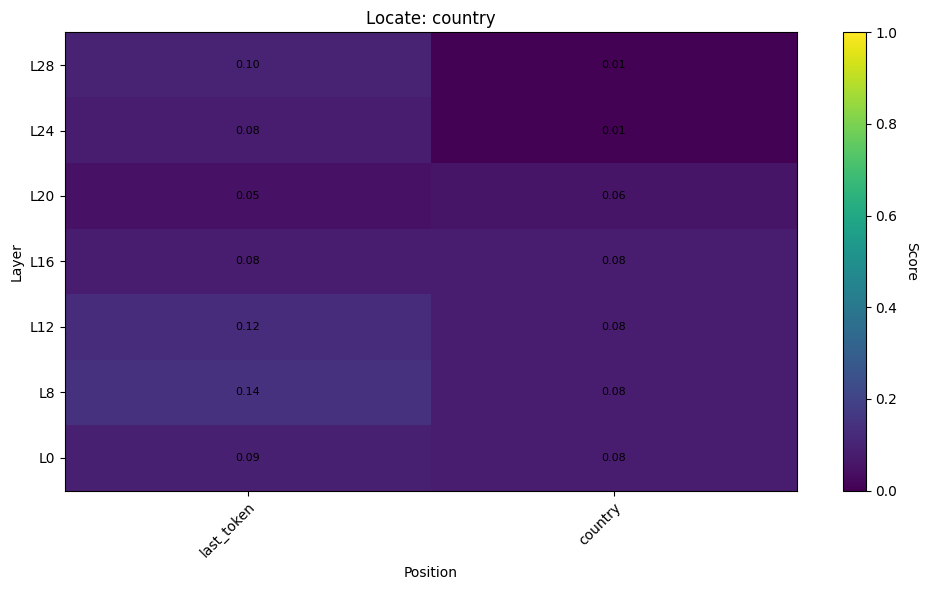

In [6]:
# Per-variable (layer × token_position) heatmaps. The brightest cell is the best site.
from glob import glob

for var_dir in sorted(locate_dir.iterdir()):
    if not var_dir.is_dir():
        continue
    heatmaps = sorted(glob(str(var_dir / 'heatmap.png')))
    if heatmaps:
        print(f'\n--- {var_dir.name} ---')
        display(Image(filename=heatmaps[0]))

Pick the brightest (layer, position) cell from the heatmap above and use it as the target for §3. For weekdays this turned out to be (layer 18, last_token). For country-border reasoning, the encoding could peak elsewhere — likely later if it's a multi-hop computation over the geographic manifold, earlier if the model just retrieves canned (country, direction) → country facts.

## §3. Subspace + geometry — the per-answer-country centroid manifold

Fit PCA to per-**answer-country** centroids at the (layer, position) located in §2, then inspect the centroid scatter colored by each of the 4 competing structural axes.

**Centroid construction (critical difference from v1/v2).** For each example, the *answer country* is `NEIGHBOR_OF[(input.country, input.direction)][0]` — the primary neighbor. To build the *France centroid*, we average activations across all (entity, direction, template) combos whose primary answer is France. This is the entity-disentangled averaging that the manifold paradigm requires; it is exactly analogous to the weekdays paper averaging across (entity, increment) pairs whose result is the same weekday.

Hypotheses:
- **Geographic isomorphism?** If the model has internalized a Europe map, the PCA scatter of country centroids should look like an actual map (PC1/PC2 ≈ affine of lat/lon).
- **Linguistic family clusters?** Romance / Germanic / Slavic / Uralic / Baltic / Hellenic / Albanian.
- **East/West Cold War axis?** Former Warsaw Pact + USSR + non-aligned communist vs Western Europe.
- **EU membership axis?** Current EU members vs non-members.

Diagnostic countries:
- **Greece** — Western/EU but linguistically Hellenic isolate, geographically peripheral.
- **Russia** — Slavic but Eastern and non-EU; geographically far east.
- **Switzerland** — Germanic but neither EU nor Eastern, geographically central.
- **Czech Republic ↔ Slovakia** and **Croatia ↔ Serbia** — nearly identical languages but different Cold War alignments.

Note: `LAYER` below defaults to 24 (from v1 capital task). Update after inspecting §2 heatmap if you ran locate.

In [ ]:
# Update LAYER and TOKEN_POSITION below after inspecting the locate heatmap.
LAYER = 24  # placeholder — replace after §2 if you ran locate
TOKEN_POSITION = 'last_token'

subspace_yaml = f'''# @package _global_
defaults:
  - /base
  - /task: country_borders
  - /model: llama31_8b
  - /analysis/subspace
  - _self_
task:
  enumerate_all: true
  target_variable: country
subspace:
  method: pca
  layers: [{LAYER}]
  k_features: 32
  token_positions: [{TOKEN_POSITION}]
  visualization:
    figure_format: png
'''
p = save_session_runner('country_borders_subspace', subspace_yaml)
print(f'Wrote {p}')
print(f'Using layer={LAYER}, token_position={TOKEN_POSITION!r}')

In [ ]:
rc = run_session('country_borders_subspace')
assert rc == 0, f'subspace run failed (rc={rc})'

In [ ]:
subspace_dir = ARTIFACTS_ROOT / 'subspace' / 'pca_k32' / 'country' / 'visualization'
print(f'Contents of {subspace_dir}:')
print(sorted(p.name for p in subspace_dir.iterdir()) if subspace_dir.exists() else '(missing)')

Contents of /home/danielaush/Documents/what-is-a-feature/causalab/agent_logs/2026-05-13--nationality-geometry--clever-falcon/artifacts/nationality_capitals/llama31_8b/subspace/pca_k32/country/visualization:
['features_2d.png', 'features_3d.html', 'features_3d.png', 'features_variance.png']


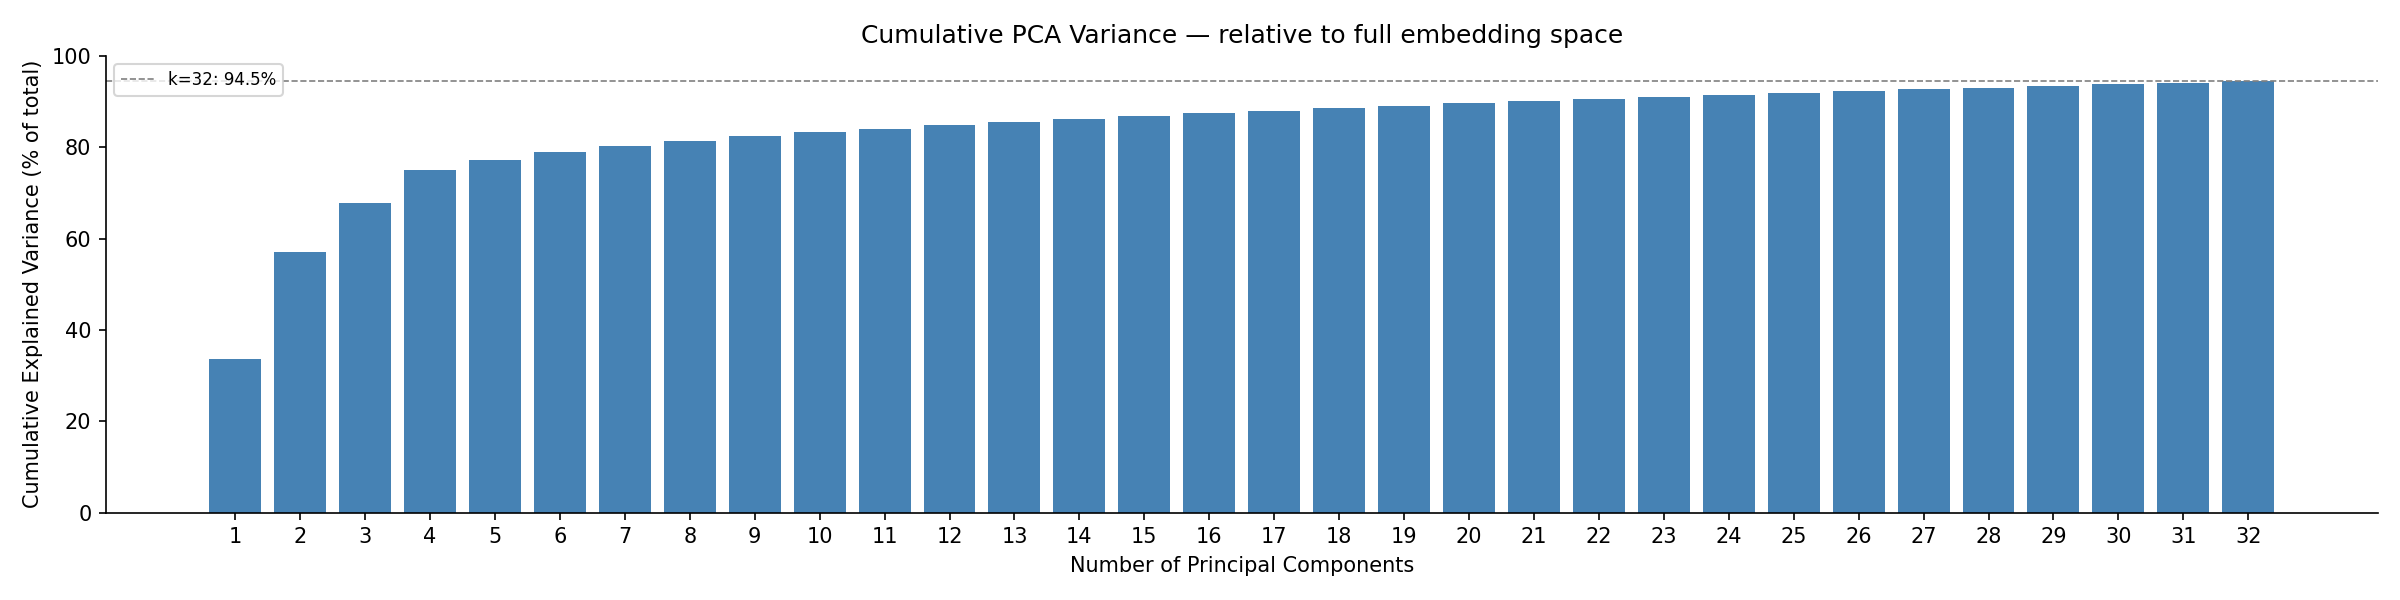

In [20]:
# Cumulative variance — how many PCs do we need to capture most of the signal?
fv = subspace_dir / 'features_variance.png'
if fv.exists():
    display(Image(filename=str(fv)))

In [ ]:
# 2D PCA scatter. The shipped subspace analysis colors by intervention-variable index
# (one color per country). For the structural-axis views (linguistic family, East/West,
# EU, geography), see the next cell.
f2d = subspace_dir / 'features_2d.png'
if f2d.exists():
    display(Image(filename=str(f2d)))

In [ ]:
# Per-answer-country centroids colored by 4 candidate structural axes.
# CENTROID CONSTRUCTION: For each example, look up the primary neighbor for
# (input.country, input.direction). Average all activations whose primary
# neighbor is X to build X's centroid. This is the entity-disentangled
# centroid construction that the manifold paradigm requires.
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from safetensors.torch import load_file

from causalab.tasks.country_borders import (
    COUNTRIES,
    NEIGHBOR_OF,
    LINGUISTIC_FAMILY_OF,
    EAST_WEST_OF,
    EU_MEMBER_OF,
    LAT_LON_OF,
)

subspace_root = ARTIFACTS_ROOT / 'subspace' / 'pca_k32' / 'country'

feat_blob = load_file(subspace_root / 'features' / 'training_features.safetensors')
features = feat_blob['features'].cpu().float().numpy()
print(f'Per-example features: {features.shape}  (expect ~960 × 32 from enumerate_all)')

with open(subspace_root / 'train_dataset.json') as f:
    train_ds = json.load(f)

# For each example, compute the answer country = primary neighbor.
# Invalid (country, direction) cells have no entry in NEIGHBOR_OF and are skipped.
example_answer = []
for ex in train_ds:
    c, d = ex['input']['country'], ex['input']['direction']
    if (c, d) in NEIGHBOR_OF:
        example_answer.append(NEIGHBOR_OF[(c, d)][0])  # primary
    else:
        example_answer.append(None)
n_valid = sum(a is not None for a in example_answer)
print(f'Valid (non-empty) examples: {n_valid} / {len(train_ds)}')

# Build centroids per ANSWER country (averaging across input entities)
centroids = np.zeros((len(COUNTRIES), features.shape[1]))
n_per_country = np.zeros(len(COUNTRIES), dtype=int)
for i, c in enumerate(COUNTRIES):
    rows = [j for j, ans in enumerate(example_answer) if ans == c]
    if rows:
        centroids[i] = features[rows].mean(axis=0)
        n_per_country[i] = len(rows)

# Drop countries with no examples (Portugal is borderline — only 1 source entity (Spain),
# 8 examples). Flag any below a threshold.
print(f'\\nExamples per answer-country centroid:')
for c, n in zip(COUNTRIES, n_per_country):
    flag = '  ⚠ thin' if n < 8 else ''
    print(f'  {c:18s}  n={n:3d}{flag}')

valid_countries = [c for c, n in zip(COUNTRIES, n_per_country) if n > 0]
valid_idx = [i for i, n in enumerate(n_per_country) if n > 0]
centroids_v = centroids[valid_idx]
print(f'\\nAnalyzable centroids: {len(valid_countries)} / {len(COUNTRIES)}')

pca = PCA(n_components=3).fit(centroids_v)
proj = pca.transform(centroids_v)

FAMILY_COLORS = {
    'Romance':  '#d62728',
    'Germanic': '#1f77b4',
    'Slavic':   '#2ca02c',
    'Uralic':   '#9467bd',
    'Baltic':   '#ff7f0e',
    'Hellenic': '#8c564b',
    'Albanian': '#e377c2',
}
EAST_WEST_COLORS = {'West': '#1f77b4', 'East': '#d62728'}

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# A. Linguistic family
ax = axes[0, 0]
for country, p in zip(valid_countries, proj):
    fam = LINGUISTIC_FAMILY_OF[country]
    ax.scatter(p[0], p[1], s=80, c=FAMILY_COLORS[fam], edgecolors='black', linewidths=0.5)
    ax.annotate(country, (p[0], p[1]), fontsize=7, alpha=0.7)
for fam, color in FAMILY_COLORS.items():
    ax.scatter([], [], c=color, label=fam, s=80, edgecolors='black', linewidths=0.5)
ax.legend(loc='best', fontsize=8)
ax.set_xlabel(f'PC0 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC1 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('A. Colored by linguistic family')

# B. East/West (Cold War)
ax = axes[0, 1]
for country, p in zip(valid_countries, proj):
    ew = EAST_WEST_OF[country]
    ax.scatter(p[0], p[1], s=80, c=EAST_WEST_COLORS[ew], edgecolors='black', linewidths=0.5)
    ax.annotate(country, (p[0], p[1]), fontsize=7, alpha=0.7)
for ew, color in EAST_WEST_COLORS.items():
    ax.scatter([], [], c=color, label=ew, s=80, edgecolors='black', linewidths=0.5)
ax.legend(loc='best', fontsize=8)
ax.set_xlabel(f'PC0 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC1 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('B. Colored by East/West (Cold War legacy)')

# C. EU membership
ax = axes[1, 0]
for country, p in zip(valid_countries, proj):
    color = '#2ca02c' if EU_MEMBER_OF[country] else '#7f7f7f'
    ax.scatter(p[0], p[1], s=80, c=color, edgecolors='black', linewidths=0.5)
    ax.annotate(country, (p[0], p[1]), fontsize=7, alpha=0.7)
ax.scatter([], [], c='#2ca02c', label='EU member', s=80, edgecolors='black', linewidths=0.5)
ax.scatter([], [], c='#7f7f7f', label='Non-EU', s=80, edgecolors='black', linewidths=0.5)
ax.legend(loc='best', fontsize=8)
ax.set_xlabel(f'PC0 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC1 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('C. Colored by EU membership')

# D. Longitude (continuous geographic axis)
ax = axes[1, 1]
lons = np.array([LAT_LON_OF[c][1] for c in valid_countries])
sc = ax.scatter(proj[:, 0], proj[:, 1], s=80, c=lons, cmap='coolwarm',
                edgecolors='black', linewidths=0.5)
for country, p in zip(valid_countries, proj):
    ax.annotate(country, (p[0], p[1]), fontsize=7, alpha=0.7)
plt.colorbar(sc, ax=ax, label='Longitude (°E)')
ax.set_xlabel(f'PC0 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC1 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('D. Colored by capital longitude')

plt.tight_layout()
plt.savefig(SESSION_DIR / 'result' / 'figures' / 'pca_by_4_axes.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f'Cumulative variance (3 PCs): {pca.explained_variance_ratio_[:3].cumsum()}')

In [ ]:
# Cosine distance matrix in original (PCA-32) space, then within/between
# cluster ratios for each of the 3 categorical labeling axes.
from sklearn.metrics.pairwise import cosine_distances

D = cosine_distances(centroids_v)
N = len(valid_countries)

FAMILY_ORDER = ['Romance', 'Germanic', 'Slavic', 'Uralic', 'Baltic', 'Hellenic', 'Albanian']
order = sorted(
    range(N),
    key=lambda i: (FAMILY_ORDER.index(LINGUISTIC_FAMILY_OF[valid_countries[i]]), valid_countries[i])
)
D_ord = D[np.ix_(order, order)]
labels_ord = [valid_countries[i] for i in order]

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(D_ord, cmap='viridis')
ax.set_xticks(range(len(labels_ord)))
ax.set_yticks(range(len(labels_ord)))
ax.set_xticklabels(labels_ord, rotation=90, fontsize=7)
ax.set_yticklabels(labels_ord, fontsize=7)
ax.set_title('Cosine distance between answer-country centroids (sorted by linguistic family)')
plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout()
plt.savefig(SESSION_DIR / 'result' / 'figures' / 'cosine_distance_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()


def within_between(label_of):
    within, between = [], []
    for i in range(N):
        for j in range(i + 1, N):
            if label_of[valid_countries[i]] == label_of[valid_countries[j]]:
                within.append(D[i, j])
            else:
                between.append(D[i, j])
    return np.mean(within), np.mean(between), len(within), len(between)


print(f'{"axis":24s}  {"within":>9s}  {"between":>9s}  {"ratio":>6s}  ({"nw":>4s},{"nb":>4s})')
for name, label_of in [
    ('linguistic_family', LINGUISTIC_FAMILY_OF),
    ('east_west',         EAST_WEST_OF),
    ('eu_member',         {c: ('EU' if EU_MEMBER_OF[c] else 'Non') for c in valid_countries}),
]:
    w, b, nw, nb = within_between(label_of)
    print(f'{name:24s}  {w:>9.4f}  {b:>9.4f}  {b/w:>6.3f}  ({nw:>4d},{nb:>4d})')

all_d = D[np.triu_indices(N, k=1)]
print(f'\\nGlobal pairwise:  mean={float(np.mean(all_d)):.4f}  median={float(np.median(all_d)):.4f}')

In [ ]:
# Targeted pair probes. With border-task centroids, the headline hypothesis is
# geographic adjacency: bordering pairs should be CLOSE on the centroid manifold
# if the model has internalized a Europe map.
country_to_idx = {c: i for i, c in enumerate(valid_countries)}
median_d = float(np.median(D[np.triu_indices(N, k=1)]))
mean_d = float(np.mean(D[np.triu_indices(N, k=1)]))

PAIRS = {
    # Direct geographic neighbors (predict CLOSE if geography is encoded)
    'geo_neighbor_FR_DE':       ('France', 'Germany'),
    'geo_neighbor_FR_IT':       ('France', 'Italy'),
    'geo_neighbor_DE_PL':       ('Germany', 'Poland'),
    'geo_neighbor_DE_AT':       ('Germany', 'Austria'),
    'geo_neighbor_PL_UA':       ('Poland', 'Ukraine'),
    'geo_neighbor_RU_BY':       ('Russia', 'Belarus'),
    'geo_neighbor_NO_SE':       ('Norway', 'Sweden'),
    'geo_neighbor_HU_AT':       ('Hungary', 'Austria'),

    # Linguistic-family pairs that are also geographic neighbors (control: both effects align)
    'fam+geo_CZ_SK':            ('Czech Republic', 'Slovakia'),
    'fam+geo_HR_RS':            ('Croatia', 'Serbia'),
    'fam+geo_LV_LT':            ('Latvia', 'Lithuania'),
    'fam+geo_FI_EE':            ('Finland', 'Estonia'),

    # Linguistic-family pairs that are NOT neighbors (predict CLOSE only if language encoded)
    'fam_only_ES_RO':           ('Spain', 'Romania'),    # both Romance, far apart
    'fam_only_PT_RO':           ('Portugal', 'Romania'), # both Romance, far apart
    'fam_only_DK_DE':           ('Denmark', 'Germany'),  # both Germanic, adjacent (fam+geo)
    'fam_only_NO_AT':           ('Norway', 'Austria'),   # both Germanic, far

    # East/West-spanning neighbors (predict FAR if Cold War overrides geography)
    'iron_curtain_DE_PL':       ('Germany', 'Poland'),
    'iron_curtain_AT_HU':       ('Austria', 'Hungary'),
    'iron_curtain_FI_RU':       ('Finland', 'Russia'),
    'iron_curtain_NO_RU':       ('Norway', 'Russia'),
    'iron_curtain_GR_BG':       ('Greece', 'Bulgaria'),

    # Distant non-neighbors (controls — predict FAR)
    'control_PT_FI':            ('Portugal', 'Finland'),
    'control_IS_GR':            ('Norway', 'Greece'),    # north-south opposites
    'control_ES_RU':            ('Spain', 'Russia'),
}

print(f'Global pairwise:  mean={mean_d:.4f}  median={median_d:.4f}\\n')
print(f'{"pair":30s}  {"distance":>9s}   {"vs median":>10s}')
for label, (a, b) in PAIRS.items():
    if a not in country_to_idx or b not in country_to_idx:
        print(f'{label:30s}  {"(skipped — one country has no centroid)":>40s}')
        continue
    d = float(D[country_to_idx[a], country_to_idx[b]])
    diff = d - median_d
    marker = '  <-- closer' if diff < -0.01 else ('  -->farther' if diff > 0.01 else '')
    print(f'{label:30s}  {d:>9.4f}   {diff:>+10.4f}{marker}')

In [ ]:
# Linear probe accuracy for each labeling axis. Tells us which structure is
# linearly decodable from the centroid representation, even if it isn't the
# dominant variance direction.
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut, cross_val_score
from collections import Counter

y_family = np.array([LINGUISTIC_FAMILY_OF[c] for c in valid_countries])
y_east_west = np.array([EAST_WEST_OF[c] for c in valid_countries])
y_eu = np.array([EU_MEMBER_OF[c] for c in valid_countries])


def loo_probe(X, y, name):
    counts = Counter(y)
    mask = np.array([counts[label] >= 2 for label in y])
    Xm, ym = X[mask], y[mask]
    dropped = sum(~mask)
    clf = LogisticRegression(max_iter=2000, C=1.0)
    acc = cross_val_score(clf, Xm, ym, cv=LeaveOneOut(), scoring='accuracy').mean()
    chance = max(Counter(ym).values()) / len(ym)
    print(f'{name:24s}  LOO acc = {acc:.3f}   chance = {chance:.3f}   '
          f'lift = {acc - chance:+.3f}   (n={len(ym)}, dropped={dropped})')
    return acc, chance


print(f'Probing on per-answer-country centroids ({centroids_v.shape[0]} countries × {centroids_v.shape[1]} dims)\\n')
loo_probe(centroids_v, y_family, 'linguistic_family')
loo_probe(centroids_v, y_east_west, 'east_west')
loo_probe(centroids_v, y_eu, 'eu_member')

In [ ]:
# Geographic isomorphism — does PC1/PC2 look like a map of Europe?
# Regress (latitude, longitude) against each PC, then find the best rotation
# of the PCA plane that maximizes joint R² with geography. The border task
# has a strong prior toward high R² here (the model literally has to traverse
# geography to answer); low R² would be the surprising result.
from sklearn.linear_model import LinearRegression
from scipy.optimize import minimize

lats = np.array([LAT_LON_OF[c][0] for c in valid_countries])
lons = np.array([LAT_LON_OF[c][1] for c in valid_countries])
geo = np.column_stack([lats, lons])

print(f'{"target":>8s}  {"R² (lat,lon)":>14s}  {"β_lat":>10s}  {"β_lon":>10s}')
for k in range(3):
    pc = proj[:, k]
    reg = LinearRegression().fit(geo, pc)
    r2 = reg.score(geo, pc)
    print(f'{"PC"+str(k):>8s}  {r2:>14.3f}  {reg.coef_[0]:>10.4f}  {reg.coef_[1]:>10.4f}')


def loss(theta_flat):
    theta = theta_flat[0]
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
    rotated = proj[:, :2] @ R
    r2_x = LinearRegression().fit(geo, rotated[:, 0]).score(geo, rotated[:, 0])
    r2_y = LinearRegression().fit(geo, rotated[:, 1]).score(geo, rotated[:, 1])
    return -(r2_x + r2_y)


res = minimize(loss, x0=[0.0], method='Nelder-Mead')
theta = res.x[0]
print(f'\\nBest in-plane rotation: {np.degrees(theta):.1f}°  → combined R² = {-res.fun:.3f}')

R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
proj_rot = proj[:, :2] @ R

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
ax = axes[0]
ax.scatter(lons, lats, s=80, c='steelblue', edgecolors='black', linewidths=0.5)
for country, lat, lon in zip(valid_countries, lats, lons):
    ax.annotate(country, (lon, lat), fontsize=7, alpha=0.7)
ax.set_xlabel('Longitude (°E)'); ax.set_ylabel('Latitude (°N)')
ax.set_title('Geography (actual capital coords)')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(proj_rot[:, 0], proj_rot[:, 1], s=80, c='steelblue',
           edgecolors='black', linewidths=0.5)
for country, p in zip(valid_countries, proj_rot):
    ax.annotate(country, (p[0], p[1]), fontsize=7, alpha=0.7)
ax.set_xlabel('PC0 (rotated)'); ax.set_ylabel('PC1 (rotated)')
ax.set_title(f'Centroid PCA, rotated {np.degrees(theta):.0f}° (combined R²={-res.fun:.2f})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(SESSION_DIR / 'result' / 'figures' / 'pca_vs_geography.png',
            dpi=150, bbox_inches='tight')
plt.show()

## §4. Findings (fill in after running)

- **Baseline strict accuracy**: 380 / 584 valid prompts = **65.1%** (376 invalid prompts excluded from denominator). Multi-neighbor: 67.6%. `prob_accuracy = 19%` — the model is uncertain on directional reasoning, much more so than on factual retrieval.
- **Per-direction**: best = S (85% multi), worst = NW (60%). Cardinals beat intercardinals — diagonal reasoning is harder.
- **Worst input countries**: Lithuania (44%), Slovakia/Croatia/Latvia/Greece (50%) — these are border-rich small countries where the model frequently confuses neighboring options.
- **Locate**: country identity peaks at layer ___ at the `___` position. (Default carry-forward: 24/last_token.)
- **Within/between cluster ratio** (cell 22):
    - linguistic_family: between/within = ___
    - east_west: between/within = ___
    - eu_member: between/within = ___
- **Linear probe accuracy** (cell 24, LOO):
    - linguistic_family: ___ (chance ___)
    - east_west: ___ (chance ~0.5)
    - eu_member: ___ (chance ___)
- **Geographic isomorphism R²** (cell 25): combined R² for (lat, lon) → rotated PCA = ___. **For the border task, the strong prior is R² > 0.5** — the model literally has to traverse geography to answer.
- **Pair probes** (cell 23):
    - Geographic-neighbor pairs: how many closer than median? ___ / 8
    - Iron-curtain neighbor pairs: how many farther than median? ___ / 5
    - Same-family non-neighbor pairs: how many closer than median? ___ / 2

**Caveats to note in the writeup:**
- Portugal and Albania have single-source centroids (entity-contaminated — flagged automatically in the geometry analysis).
- `prob_accuracy = 19%` means activations at last-token are mixed — centroid quality will be noisier than a high-confidence task. We accept this as part of the experimental design.

**Interpretive call:**
- **Geography wins** (the strong prior) if R² > 0.5 AND geographic-neighbor pairs are closer than median AND PCA scatter visually resembles a Europe map.
- **Cold War overrides geometry** if iron-curtain pairs (Germany↔Poland, Austria↔Hungary, Finland↔Russia) are far apart despite being neighbors.
- **Language overrides geometry** if family-non-neighbor pairs (Spain↔Romania) are close despite being far apart geographically.
- **Mixed** is the realistic outcome — write up which axis is dominant.